<a href="https://colab.research.google.com/github/GiovanniRava/outlier-quantization-tradeoff/blob/main/notebooks/outlier-tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -U -q transformers accelerate

In [3]:
!pip install -q datasets

# Analisi Empirica della Quantizzazione Uniforme su Value Vector in LLM

**Obiettivo dello studio:** Questo notebook implementa uno studio empirico per quantificare il *trade-off* tra l'efficacia di un attacco di iniezione (outlier) nel KV-cache di un Large Language Model e la sua rilevabilità statistica.

## Configurazione dell'Ambiente

Per l'esecuzione dell'esperimento, ci avvaliamo dell'ecosistema Hugging Face. In questa prima fase, procediamo all'installazione e all'aggiornamento delle librerie fondamentali:
* `transformers`: essenziale per il download, il caricamento e l'interazione con l'architettura del modello linguistico open-source.
* `accelerate`: una libreria di ottimizzazione fondamentale per la gestione efficiente della VRAM, necessaria per mappare e bilanciare i pesi del modello direttamente sulla GPU fornita dall'ambiente di calcolo, evitando colli di bottiglia nella memoria di sistema.

In [13]:
import torch
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from tqdm.notebook import tqdm
from google.colab import drive

## Fase 1: Inizializzazione e Caricamento del Modello Linguistico

Per la generazione delle attivazioni (i *Value vector*), abbiamo selezionato il modello **Qwen2.5-Coder-3B**. Questa scelta è motivata da due fattori ingegneristici:
1. **Dominio di addestramento:** Essendo specializzato sul codice sorgente, genererà vettori di attenzione semanticamente ricchi quando stimolato con gli snippet di codice previsti dal nostro design sperimentale.
2. **Dimensionamento:** Con i suoi 3 miliardi di parametri, è sufficientemente compatto da risiedere nella VRAM di una singola GPU T4 (16 GB), pur mantenendo architetture di Attention moderne.

**Ottimizzazioni per l'Inferenza:**
Poiché il nostro obiettivo è l'estrazione passiva delle attivazioni e non il fine-tuning del modello (come previsto dai vincoli del task), applichiamo due ottimizzazioni critiche per massimizzare il risparmio di memoria:
* **Disabilitazione globale dei gradienti:** Tramite `torch.set_grad_enabled(False)`, impediamo a PyTorch di allocare memoria per il grafo computazionale, operazione computazionalmente dispendiosa e superflua in fase di pura inferenza.
* **Half-Precision (BF16):** I pesi statici del modello vengono caricati in formato `bfloat16`. Questo dimezza istantaneamente il footprint in memoria rispetto al formato nativo a 32-bit (FP32), senza degradare significativamente la qualità delle attivazioni interne. Infine, la modalità `.eval()` assicura la disattivazione di layer stocastici come il Dropout.

In [5]:
torch.set_grad_enabled(False)
model_id = "Qwen/Qwen2.5-Coder-3B"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Hardware rilevato: {device.upper()}")

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16, # Dimezza l'occupazione di memoria
    device_map="auto"           # Alloca automaticamente i layer sulla GPU se disponibile
)
model.eval()

print("Modello Qwen2.5-Coder-3B caricato")

Hardware rilevato: CUDA


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/139 [00:00<?, ?B/s]

Modello Qwen2.5-Coder-3B caricato


## Fase 1.2: Preparazione dei Prompt tramite Dataset DiverseVul

In questa fase predisponiamo i dati di input (i *prompt*) che andranno a stimolare la rete neurale per la generazione dei tensori. Per simulare un contesto di analisi di sicurezza realistico e produrre *Value vector* semanticamente rilevanti, attingiamo a **DiverseVul**, un dataset accademico standardizzato che raccoglie funzioni C/C++ vulnerabili (CWE) provenienti da repository open-source.

**Scelte metodologiche e ottimizzazioni:**
* **Focus sulle Vulnerabilità:** Filtriamo il dataset per estrarre esclusivamente frammenti di codice etichettati come vulnerabili (`target == 1`). È infatti durante l'elaborazione di pattern di codice critici che vogliamo testare la resistenza del modello al collasso della quantizzazione.
* **Lazy Loading (Streaming):** Per evitare colli di bottiglia legati all'I/O e al consumo di memoria RAM su Google Colab, il dataset viene caricato avvalendosi della libreria `datasets` in modalità `streaming=True`. Questo approccio iterativo (Generators-based) scarica i record *on-the-fly*, permettendoci di interrompere l'operazione di rete non appena viene raggiunto il campione statistico prefissato (es. 1000 funzioni), azzerando i tempi di setup.

In [20]:
dataset = load_dataset("claudios/DiverseVul", split="test", streaming=True)
#Ne scelgo 4 o5 non mi interessa se. sono vulnerabili o meno
NUM_PROMPTS = 1000
code_prompts = []
for row in dataset:
    code_prompts.append(row['func'])
    if len(code_prompts) >= NUM_PROMPTS:
        break

print(f"Estrazione terminata")
#print("\n--- Anteprima Prompt 0 ---")
#print(code_prompts)

Estrazione terminata


## Fase 1.3: Implementazione del Forward Hook per l'estrazione dei tensori

Per quantificare l'impatto della quantizzazione sui singoli token, dobbiamo intercettare le attivazioni interne del modello a runtime. Avvalendoci delle API di PyTorch, registriamo un **Forward Hook** sul modulo di proiezione dei *Value* (`v_proj`) all'interno del meccanismo di Attention.

**Scelte architetturali:**
* **Target Layer:** Selezioniamo un layer intermedio (es. il layer 14 su 36 totali di Qwen-3B). I layer intermedi tendono a codificare astrazioni sintattiche e semantiche di alto livello, rendendoli candidati ideali per osservare il collasso dell'informazione causato dall'outlier.
* **Gestione Memoria:** All'interno dell'hook, il tensore intercettato viene immediatamente scollegato dal grafo di calcolo (`.detach()`) e spostato nella RAM di sistema (`.cpu()`). Questo previene il riempimento istantaneo della VRAM della GPU, permettendoci di accumulare migliaia di vettori senza incorrere in errori di `Out Of Memory` (OOM).

In [21]:
extracted_value_vectors = []

def value_extraction_hook(module, input, output):
    """
    Questa funzione viene chiamata automaticamente da PyTorch ogni volta che
    il livello v_proj calcola i suoi valori.
    L'output del livello lineare v_proj ha solitamente forma: (batch_size, seq_length, hidden_size)
    """
    # Facciamo una copia del tensore, lo stacchiamo dalla GPU e lo passiamo alla CPU
    # Preleviamo solo l'ultimo token della sequenza (la rappresentazione finale del contesto)
    # Forma estratta: (hidden_size)
    last_token_value = output[0, -1, :].detach().cpu()

    extracted_value_vectors.append(last_token_value)

TARGET_LAYER_IDX = 14
target_module = model.model.layers[TARGET_LAYER_IDX].self_attn.v_proj

hook_handle = target_module.register_forward_hook(value_extraction_hook)

print(f"Sonda agganciata con successo su: model.model.layers[{TARGET_LAYER_IDX}].self_attn.v_proj")


print("\nEsecuzione di un test sul Prompt 0...")
inputs = tokenizer(code_prompts[0], return_tensors="pt", truncation=True, max_length=512)

inputs = {k: v.to(device) for k, v in inputs.items()}

_ = model(**inputs)

cattura = extracted_value_vectors[0]
print(f"Tensore catturato! Tipo: {cattura.dtype}, Forma (Dimensioni): {cattura.shape}")
hook_handle.remove()

Sonda agganciata con successo su: model.model.layers[14].self_attn.v_proj

Esecuzione di un test sul Prompt 0...
Tensore catturato! Tipo: torch.bfloat16, Forma (Dimensioni): torch.Size([256])


## Fase 1.4: Estrazione Massiva e Persistenza dei Dati

Verificata l'integrità del meccanismo di hooking, procediamo con l'estrazione automatizzata sull'intero corpus di prompt (1000 snippet).

**Strategia di esecuzione e persistenza:**
* **Iterazione e Troncamento:** I prompt vengono passati sequenzialmente al modello. Per garantire stabilità ed evitare saturazioni della VRAM dovute a sequenze anomale, imponiamo un limite rigoroso (`max_length=512` token) e l'attivazione del troncamento. L'hook catturerà il *Value vector* associato all'ultimo token elaborato di ciascuna sequenza.
* **Stacking Tensoriale:** Al termine del ciclo, la lista di vettori unidimensionali viene impilata (`torch.stack`) in un unico grande tensore bidimensionale di forma `(NUM_PROMPTS, 256)`. Questo formato a matrice è lo standard ideale per le successive manipolazioni matematiche vettorializzate.
* **Salvataggio in Cloud:** Trattandosi dell'output computazionalmente più costoso dell'intero esperimento, il tensore finale viene serializzato e salvato su **Google Drive** in formato nativo PyTorch (`.pt`). Questo ci immunizza da eventuali crash o disconnessioni della sessione interattiva di Colab.

In [22]:
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/Progetto_Outlier_LLM'
os.makedirs(save_dir, exist_ok=True)

extracted_value_vectors = []
hook_handle = target_module.register_forward_hook(value_extraction_hook)

for prompt in tqdm(code_prompts, desc="Estrazione Attivazioni"):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    _ = model(**inputs)

hook_handle.remove()

dataset_tensor = torch.stack(extracted_value_vectors)
save_path = os.path.join(save_dir, 'qwen_value_vectors_layer14.pt')
torch.save(dataset_tensor, save_path)

print(dataset_tensor.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Estrazione Attivazioni:   0%|          | 0/1000 [00:00<?, ?it/s]

torch.Size([1000, 256])


## Fase 2: Sviluppo del Motore di Quantizzazione e Attacco

In questa sezione implementiamo il simulatore matematico della compressione della memoria (KV-cache). L'obiettivo è replicare fedelmente il processo di **quantizzazione uniforme simmetrica per-token**, lo standard industriale per la riduzione dell'impronta di memoria dei LLM durante l'inferenza a lungo contesto.

**Dettagli Algoritmici:**
1. **Compressione (Quantizzazione/Dequantizzazione):** Dato un vettore $v$, viene calcolata la scala dinamica $s = \max(|v|)$. L'intervallo $[-s, s]$ viene suddiviso in $2^{\text{bits}}$ livelli. I valori in virgola mobile vengono divisi per il passo di quantizzazione ($\Delta$), arrotondati all'intero più vicino, e infine dequantizzati (moltiplicati nuovamente per $\Delta$) per approssimare il vettore originale.
2. **Iniezione dell'Outlier (Trigger):** Viene definita una funzione di attacco che isola il massimo naturale del vettore e inietta all'indice $i=0$ un valore sintetico pari a $c \cdot \max(|v_{originale}|)$. Questa operazione forza l'espansione artificiale della scala $s$, innescando matematicamente il collasso degli altri elementi naturali verso lo zero durante la fase di arrotondamento.

In [23]:
def simulate_quantization(v, bits=8):
    s = torch.max(torch.abs(v))
    if s == 0:
        return v.clone()

    q_max = (2 ** (bits - 1)) - 1
    delta = s / q_max

    v_q = torch.round(v / delta).clamp(-q_max, q_max)
    return v_q * delta

def inject_outlier_and_quantize(v, c, bits=8, outlier_idx=0):
    v_attacked = v.clone().to(torch.float32)
    natural_max = torch.max(torch.abs(v_attacked))

    outlier_value = natural_max * c
    v_attacked[outlier_idx] = outlier_value

    v_reconstructed = simulate_quantization(v_attacked, bits=bits)
    return v_attacked, v_reconstructed

print("Motore di quantizzazione caricato.")

Motore di quantizzazione caricato.


## Fase 3: Implementazione delle Metriche (RE e Z-Score Robusto)

Per valutare oggettivamente il *trade-off* tra efficacia e furtività dell'attacco, traduciamo in codice le metriche definite nel protocollo sperimentale.

In conformità con la definizione matematica rigorosa, implementiamo tre sottofasi:
* **Fase 3.1 - Masking:** Una funzione di utilità per escludere categoricamente l'indice $i$ (la posizione dell'outlier) dalle misurazioni, operando esclusivamente sul sub-tensore naturale $v_{\neq i}$.
* **Fase 3.2 - Relative Error (RE):** Misura la distorsione globale indotta dalla quantizzazione calcolando la norma $L_2$ della differenza tra il vettore originale mascherato e quello ricostruito mascherato, normalizzata sulla norma dell'originale. Valori prossimi a 1 indicano un collasso critico.
* **Fase 3.3 - Modified Z-Score ($Z_{mod}$):** Determina il grado di anomalia dell'outlier iniettato utilizzando stimatori robusti di posizione e dispersione (Mediana e MAD). La baseline statistica viene calcolata unicamente sui dati non compromessi per evitare che l'outlier influenzi la propria stessa metrica di rilevamento (*masking effect*).

In [24]:
# GHestione delle maschere per escludere l'outlier
def get_masked_vector(v, outlier_idx=0):
    mask = torch.arange(v.size(0)) != outlier_idx
    return v[mask]

# Relative Error (Efficacia)
def calculate_re(v_orig, v_recon, outlier_idx=0):
    v_orig_masked = get_masked_vector(v_orig, outlier_idx)
    v_recon_masked = get_masked_vector(v_recon, outlier_idx)

    diff_norm = torch.norm(v_orig_masked - v_recon_masked, p=2)
    orig_norm = torch.norm(v_orig_masked, p=2)

    if orig_norm == 0:
        return 0.0

    return (diff_norm / orig_norm).item()

#  Modified Z-Score (Rilevabilità)
def calculate_zmod(v_orig_clean, outlier_value, outlier_idx=0):
    v_masked = get_masked_vector(v_orig_clean, outlier_idx)

    median_val = torch.median(v_masked)
    mad = torch.median(torch.abs(v_masked - median_val))

    if mad == 0:
        mad = torch.tensor(1e-6)

    z_mod = 0.6745 * (outlier_value - median_val) / mad

    return z_mod.item()

## Fase 4: Esecuzione dell'Esperimento su Larga Scala

Avendo predisposto il dataset di attivazioni ($v \in \mathbb{R}^d$), il motore di quantizzazione e le metriche di valutazione, procediamo con l'esecuzione dell'esperimento principale per quantificare il *trade-off* descritto nel protocollo. L'orchestrazione dello studio si articola in tre sottofasi:

* **Fase 4.1 - Definizione della Griglia Sperimentale:** Definiamo un array di moltiplicatori di magnitudine $c \in \{2, 5, 10, 20, 50, 100, 200\}$. Questa griglia, a spaziatura pseudo-logaritmica, è progettata per coprire l'intero spettro operativo dell'attacco, partendo da anomalie minime (potenzialmente inefficaci) fino a magnitudini estreme (altamente distruttive ma facilmente rilevabili).
* **Fase 4.2 - Ciclo di Simulazione (Main Loop):** Implementiamo un'iterazione annidata. Per ciascun *Value vector* estratto dal modello linguistico, applichiamo sistematicamente ogni valore della griglia $c$. Per ogni configurazione, invochiamo il motore di iniezione/quantizzazione ed estraiamo le metriche di Efficacia ($RE$) e Rilevabilità ($Z_{mod}$).
* **Fase 4.3 - Registrazione e Persistenza dei Dati:** I risultati di ogni iterazione vengono strutturati all'interno di un dizionario e successivamente immagazzinati in un `DataFrame` della libreria Pandas. Il dataset tabulare risultante viene infine esportato in formato CSV (su Google Drive), garantendo la persistenza del dato e predisponendo il terreno per la successiva fase di analisi esplorativa e visualizzazione grafica.

In [25]:
c_values = [2, 5, 10, 20, 50, 100, 200]
results = []

BITS = 8
OUTLIER_IDX = 0

for vec_id, v in enumerate(dataset_tensor):
    for c in c_values:
        v_attacked, v_recon = inject_outlier_and_quantize(v, c=c, bits=BITS, outlier_idx=OUTLIER_IDX)

        re_val = calculate_re(v, v_recon, outlier_idx=OUTLIER_IDX)

        outlier_value = v_attacked[OUTLIER_IDX].item()
        z_mod_val = calculate_zmod(v, outlier_value, outlier_idx=OUTLIER_IDX)

        results.append({
            'vector_id': vec_id,
            'c_multiplier': c,
            'RE': re_val,
            'Z_mod': z_mod_val
        })

df_results = pd.DataFrame(results)

save_csv_path = os.path.join(save_dir, 'esperimento_outlier_risultati.csv')
df_results.to_csv(save_csv_path, index=False)

print(f"Esperimento completato su {len(dataset_tensor)} vettori.")
print(f"Risultati salvati in: {save_csv_path}")

display(df_results.head(10))

Esperimento completato su 1000 vettori.
Risultati salvati in: /content/drive/MyDrive/Progetto_Outlier_LLM/esperimento_outlier_risultati.csv


,vector_id,c_multiplier,RE,Z_mod
0,0,2,0.017433,8.5625
1,0,5,0.041292,21.3750
2,0,10,0.085538,42.7500
3,0,20,0.164128,85.5000
4,0,50,0.429003,214.0000
5,0,100,0.750500,428.0000
6,0,200,0.962715,856.0000
7,1,2,0.027000,14.6250
8,1,5,0.065328,36.5000
9,1,10,0.133180,73.0000


## Fase 5: Visualizzazione del Trade-Off e Analisi dei Risultati

In questa fase conclusiva, procediamo all'analisi esplorativa dei risultati sperimentali per quantificare la relazione tra il moltiplicatore $c$, l'efficacia dell'attacco (RE) e la sua rilevabilità statistica ($Z_{mod}$).

**Metodologia di Analisi:**
1. **Aggregazione Statistica:** I risultati ottenuti sui singoli vettori vengono aggregati calcolando la media per ciascun livello di magnitudine $c$.
2. **Visualizzazione Bivariata:** Generiamo un grafico a doppio asse Y. L'asse delle ascisse (moltiplicatore $c$) è tracciato in scala logaritmica per apprezzare adeguatamente la progressione esponenziale. La curva rossa rappresenta il collasso dell'informazione (RE), mentre la curva blu monitora il punteggio di anomalia ($Z_{mod}$).
3. **Punto di Equilibrio:** Definiamo un criterio algoritmico per individuare il *sweet spot* dell'attacco. Cerchiamo il valore di $c$ che massimizza RE prima che $Z_{mod}$ esploda in modo ingestibile (considerando che i LLM presentano attivazioni naturalmente heavy-tailed, la soglia teorica di 3.5 viene rapidamente superata).

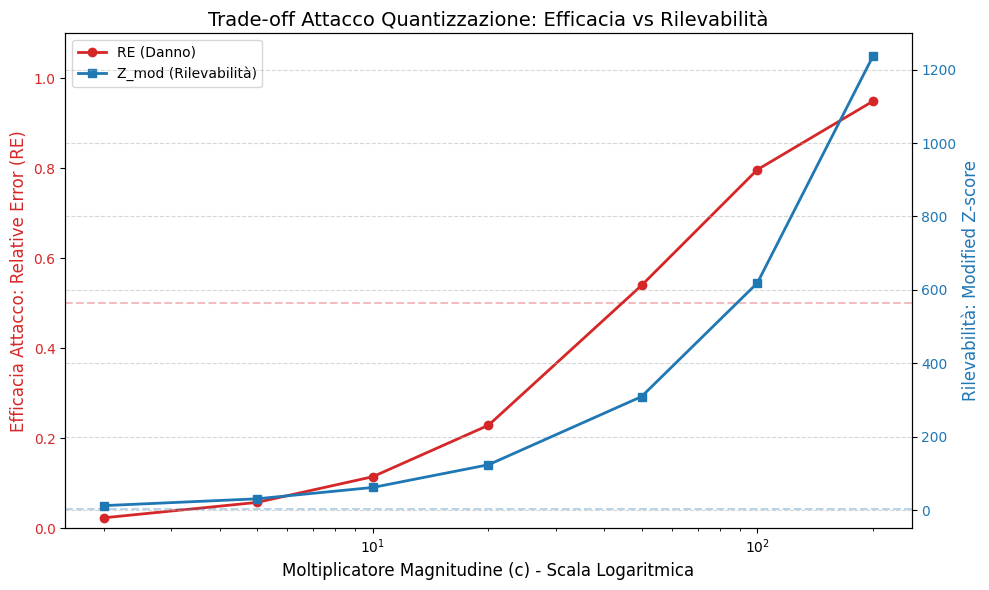


--- RISULTATI DELL'ANALISI ---
Punto di equilibrio identificato a c = 50.0
-> Danno causato (RE): 0.54 (54.0%)
-> Rilevabilità (Z_mod): 309.37

Nota: Nei LLM le attivazioni sono naturalmenty heavy-tailed.
Uno Z_mod elevato potrebbe confondersi con il normale rumore di fondo del modello.


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Aggregazione dei dati (media per ogni valore di c)
df_summary = df_results.groupby('c_multiplier')[['RE', 'Z_mod']].mean().reset_index()

# 2. Generazione del grafico a doppio asse Y
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Moltiplicatore Magnitudine (c) - Scala Logaritmica', fontsize=12)
ax1.set_xscale('log')

# Asse Y sinistro: Relative Error (Danno)
color1 = 'tab:red'
ax1.set_ylabel('Efficacia Attacco: Relative Error (RE)', color=color1, fontsize=12)
line1 = ax1.plot(df_summary['c_multiplier'], df_summary['RE'], marker='o', color=color1, label='RE (Danno)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 1.1)
ax1.axhline(y=0.5, color='tab:red', linestyle='--', alpha=0.3) # Soglia teorica danno al 50%

# Asse Y destro: Z-score (Rilevabilità)
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Rilevabilità: Modified Z-score', color=color2, fontsize=12)
line2 = ax2.plot(df_summary['c_multiplier'], df_summary['Z_mod'], marker='s', color=color2, label='Z_mod (Rilevabilità)', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(y=3.5, color='tab:blue', linestyle='--', alpha=0.3) # Soglia canonica anomalia

# Legenda unificata
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Trade-off Attacco Quantizzazione: Efficacia vs Rilevabilità', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Identificazione algoritmica di un punto di compromesso
# Troviamo il primo 'c' in cui facciamo almeno il 30% di danno (RE > 0.3)
collasso_significativo = 0.30
candidati = df_summary[df_summary['RE'] > collasso_significativo]

print("\n--- RISULTATI DELL'ANALISI ---")
if not candidati.empty:
    best_tradeoff = candidati.iloc[0]
    print(f"Punto di equilibrio identificato a c = {best_tradeoff['c_multiplier']}")
    print(f"-> Danno causato (RE): {best_tradeoff['RE']:.2f} ({best_tradeoff['RE']*100:.1f}%)")
    print(f"-> Rilevabilità (Z_mod): {best_tradeoff['Z_mod']:.2f}")
    print("\nNota: Nei LLM le attivazioni sono naturalmenty heavy-tailed.")
    print("Uno Z_mod elevato potrebbe confondersi con il normale rumore di fondo del modello.")
else:
    print("Nessun valore di c nella griglia ha raggiunto la soglia di collasso desiderata.")